# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## Task 0 - Exploratory Data Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Loading Data

In [2]:
df_donors = pd.read_csv('Donors_dataset.csv')

In [3]:
# Data Set Visualization
df_donors.head()

,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3


In [4]:
# Data Structure Verification
print(f'df_donors')
print({df_donors.info()})

df_donors
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19372 entries, 0 to 19371
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TARGET_B                     19372 non-null  int64  
 1   TARGET_D                     4843 non-null   float64
 2   CONTROL_NUMBER               19372 non-null  int64  
 3   MONTHS_SINCE_ORIGIN          19372 non-null  int64  
 4   DONOR_AGE                    14577 non-null  float64
 5   IN_HOUSE                     19372 non-null  int64  
 6   URBANICITY                   19372 non-null  object 
 7   SES                          19372 non-null  object 
 8   CLUSTER_CODE                 19372 non-null  object 
 9   HOME_OWNER                   19372 non-null  object 
 10  DONOR_GENDER                 19372 non-null  object 
 11  INCOME_GROUP                 14980 non-null  float64
 12  PUBLISHED_PHONE              19372 non-null  int64  
 13  OVERLA

## 0.2. Understanding Data

In this task you should **understand better the features**, their distribution of values, potential errors, etc and plan/describe what data preprocessing steps should be performed next. Very important also is the distribution of values in the target (class distribution). 

Here you can find a notebook with some examples of what you can do in **Exploratory Data Analysis**: https://www.kaggle.com/artgor/exploration-of-data-step-by-step/notebook. You can also use Orange widgets for this.

In [10]:
# Missing Data Identification (Null Values Check)
missing_data = df_donors.isnull().sum()
print(missing_data[missing_data > 0])

TARGET_D                       14529
DONOR_AGE                       4795
INCOME_GROUP                    4392
WEALTH_RATING                   8810
MONTHS_SINCE_LAST_PROM_RESP      246
dtype: int64


In [8]:
# Selecting only numerical variables for correlation analysis
numerical_columns = df_donors.select_dtypes(include=['float64', 'int64']).columns

# Initialize a dictionary to hold the correlation values
correlation_dict = {}

# Calculate Pearson correlation for TARGET_D with each numerical variable
for column in numerical_columns:
    if column != 'TARGET_D' and column != 'TARGET_B':  # Skip the target variable and TARGET_B
        correlation = df_donors['TARGET_D'].corr(df_donors[column])
        correlation_dict[column] = correlation

# Convert the dictionary to a DataFrame for better visualization
correlation_table = pd.DataFrame(correlation_dict.items(), columns=['Variable', 'Pearson Coefficient'])

# Sort the DataFrame by 'Pearson Coefficient' in descending order
correlation_table_sorted = correlation_table.sort_values(by='Pearson Coefficient', ascending=False)

# Display the sorted correlation table
print(correlation_table_sorted.reset_index(drop=True))

                       Variable  Pearson Coefficient
0           RECENT_AVG_GIFT_AMT             0.707250
1                 LAST_GIFT_AMT             0.645388
2                 FILE_AVG_GIFT             0.516724
3         LIFETIME_AVG_GIFT_AMT             0.516724
4      RECENT_AVG_CARD_GIFT_AMT             0.477654
5         LIFETIME_MAX_GIFT_AMT             0.443145
6           LIFETIME_GIFT_RANGE             0.338629
7         LIFETIME_MIN_GIFT_AMT             0.295783
8          LIFETIME_GIFT_AMOUNT             0.247667
9             PER_CAPITA_INCOME             0.135409
10  MONTHS_SINCE_LAST_PROM_RESP             0.133834
11            MEDIAN_HOME_VALUE             0.126180
12                 INCOME_GROUP             0.126074
13      MEDIAN_HOUSEHOLD_INCOME             0.118255
14                WEALTH_RATING             0.114298
15       MONTHS_SINCE_LAST_GIFT             0.090215
16               NUMBER_PROM_12             0.064494
17                     IN_HOUSE             0.

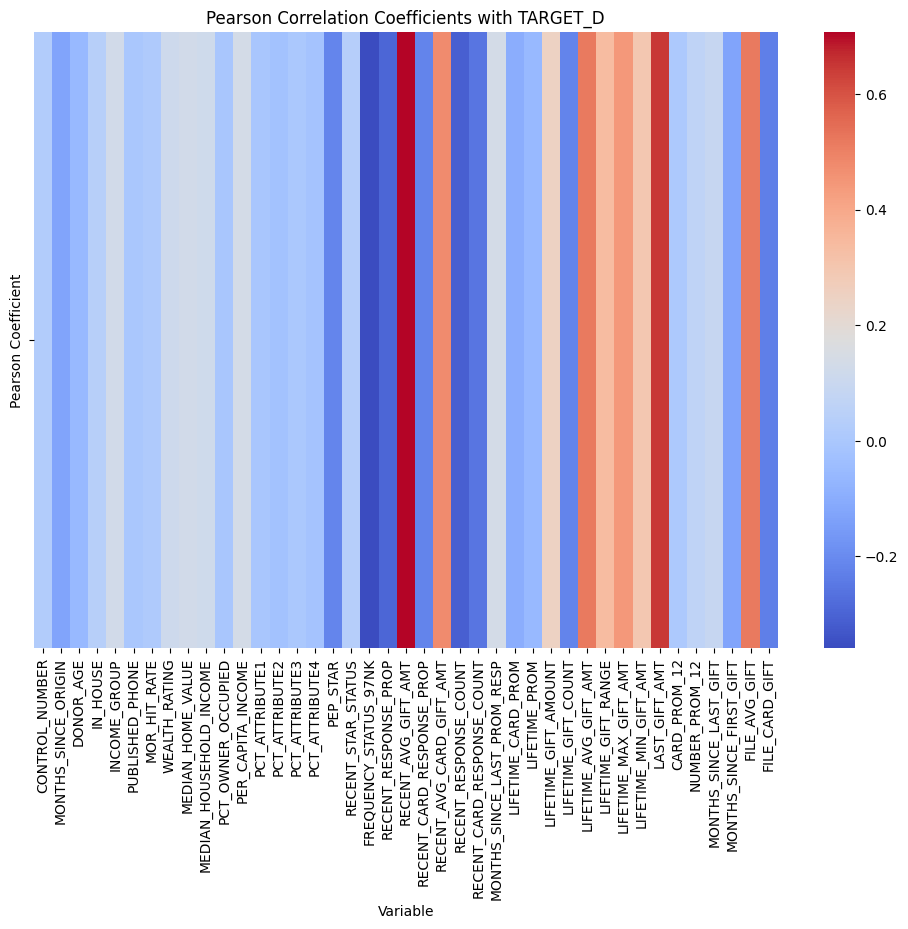

In [ ]:
# Heatmap Visualization of Correlation Coefficients
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_table.set_index('Variable').T, cmap='coolwarm', cbar=True, fmt=".2f")
plt.title('Pearson Correlation Coefficients with TARGET_D')
plt.show()

In [ ]:
# Strongly Positive Correlations (potential features for modeling)
#
#     RECENT_AVG_GIFT_AMT:         0.707250
#     LAST_GIFT_AMT:               0.645388
#     FILE_AVG_GIFT:               0.516724
#     LIFETIME_AVG_GIFT_AMT:       0.516724
#     RECENT_AVG_CARD_GIFT_AMT:    0.477654
#     LIFETIME_MAX_GIFT_AMT:       0.443145
#     LIFETIME_GIFT_RANGE:         0.338629
#     LIFETIME_MIN_GIFT_AMT:       0.295783
#     LIFETIME_GIFT_AMOUNT:        0.247667
#     PER_CAPITA_INCOME:           0.135409
#     MONTHS_SINCE_LAST_PROM_RESP: 0.133834
#     MEDIAN_HOME_VALUE:           0.126180
#     INCOME_GROUP:                 0.126074
#     MEDIAN_HOUSEHOLD_INCOME:      0.118255
#     WEALTH_RATING:                0.114298
#
# Strongly Negative Correlations (potential features for modeling)
#
#     FREQUENCY_STATUS_97NK:         -0.358655
#     RECENT_RESPONSE_COUNT:         -0.312299
#     RECENT_RESPONSE_PROP:          -0.292625
#     RECENT_CARD_RESPONSE_COUNT:    -0.256911
#     FILE_CARD_GIFT:                -0.229592
#     RECENT_CARD_RESPONSE_PROP:     -0.221056
#     LIFETIME_GIFT_COUNT:           -0.220247
#     PEP_STAR:                      -0.215399
#     MONTHS_SINCE_FIRST_GIFT:      -0.127522
#     MONTHS_SINCE_ORIGIN:           -0.126858
#     DONOR_AGE:                    -0.056139
#     LIFETIME_PROM:                -0.057903
#     LIFETIME_CARD_PROM:           -0.097675

In [11]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Identifying categorical variables
categorical_columns = df_donors.select_dtypes(include=['object']).columns

# Results for ANOVA
anova_results = {}

for column in categorical_columns:
    if column != 'TARGET_D':  # Ignoring the target variable
        # Fitting the ANOVA model
        model = ols(f'TARGET_D ~ C({column})', data=df_donors).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Storing results
        anova_results[column] = anova_table['PR(>F)'].iloc[0]  # P-value

# Converting results to DataFrame for better visualization
anova_results_df = pd.DataFrame(anova_results.items(), columns=['Variable', 'P-Value'])

# Displaying the results
print(anova_results_df)

              Variable       P-Value
0           URBANICITY  1.612702e-09
1                  SES  3.165017e-13
2         CLUSTER_CODE  3.142542e-08
3           HOME_OWNER  5.895921e-01
4         DONOR_GENDER  4.872228e-12
5       OVERLAY_SOURCE  2.945736e-01
6  RECENCY_STATUS_96NK  1.487957e-64


In [ ]:
# Interpretation of Results
#
# The printed DataFrame shows the categorical variables with their respective p-values:
#
#     URBANICITY: 1.612702e-09 — Significant.
#     SES: 3.165017e-13 — Highly significant.
#     CLUSTER_CODE: 3.142542e-08 — Significant.
#     HOME_OWNER: 5.895921e-01 — Not significant.
#     DONOR_GENDER: 4.872228e-12 — Highly significant.
#     OVERLAY_SOURCE: 2.945736e-01 — Not significant.
#     RECENCY_STATUS_96NK: 1.487957e-64 — Highly significant.
#
# Considerations
#
#     P-values < 0.05: Variables with very low p-values (such as URBANICITY, SES,
#     CLUSTER_CODE, DONOR_GENDER, and RECENCY_STATUS_96NK) are statistically significant
#     and may be included in the prediction model.
#     P-values > 0.05: Variables like HOME_OWNER and OVERLAY_SOURCE do not have a
#     significant association with TARGET_D and could be excluded in the context of the model.

...

## 0.3. Preprocessing Data

Here you might perform data preprocessing that will be used for both supervised and unsupervised learning tasks.

...

## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

**You should:**

* Choose **5 classifiers** from **at least 3 of the following categories**: Tree models, Probabilistic models, Distance-based models and Linear models. You can also try one Ensemble Classifier (https://scikit-learn.org/1.5/modules/ensemble.html). 
* Use **cross-validation** to evaluate the results.
* Describe the parameters used for each classifier and how their choice impacted or not the results.
* Choose the **best classifier** and fundament you choice.
* Present and discuss the results for different evaluation measures, present confusion matrices. Remember that not only overall results are important. Check what happens when learning to predict each class. Remember also that some metrics might be more adequate than others according to the problem at hand.

* **Discuss critically your choices and the results!**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

This project aims to develop a machine learning classification model using a Decision Tree algorithm to predict donation types based on donor data. By leveraging a dataset containing various attributes related to previous donations, such as average gift amounts and donor demographics, the model will categorize individuals into different donation types, specifically classes A to E, based on the amount they are likely to donate.

To achieve this, the project follows methodical steps, starting with data preparation. Initially, relevant numeric and categorical features are defined and imported, including metrics like recent average gift amount and urbanicity. The model will only focus on entries where the target variable, TARGET_D, is not null, thus ensuring data quality. A custom function is utilized to classify donation amounts into defined categories—A, B, C, D, and E—based on a set amount range.

Following data cleaning and imputation of missing values, which uses median values for numeric features and the most frequent values for categorical features, the dataset is transformed using one-hot encoding for categorical variables. The data is then split into training and testing sets, ensuring stratification to maintain class representation.

The Decision Tree model is subsequently trained on the training data, and predictions are made on the test set. Finally, the model's performance is evaluated through metrics such as the confusion matrix and F1 score, providing insights into its effectiveness in classifying donor behaviors. This systematic approach not only enhances understanding of donor characteristics but also aims to improve targeted fundraising efforts.

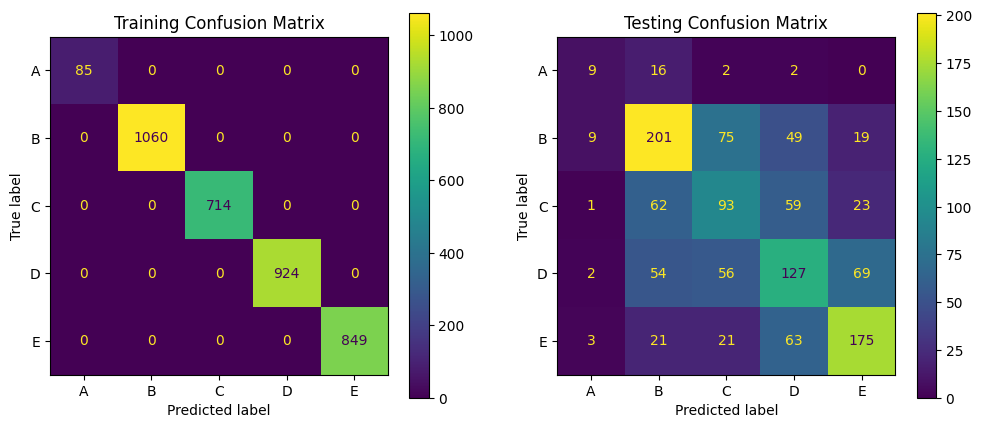

Training Confusion Matrix Results:
[85, 0, 0, 0, 0]
[0, 1060, 0, 0, 0]
[0, 0, 714, 0, 0]
[0, 0, 0, 924, 0]
[0, 0, 0, 0, 849]
Testing Confusion Matrix Results:
[9, 16, 2, 2, 0]
[9, 201, 75, 49, 19]
[1, 62, 93, 59, 23]
[2, 54, 56, 127, 69]
[3, 21, 21, 63, 175]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.38      0.31      0.34        29
           B       0.57      0.57      0.57       353
           C       0.38      0.39      0.38       238
           D       0.42      0.41      0.42       308
           E       0.61      0.62      0.62       283

    accuracy                           0.50      1211
   macro avg       0.47      0.46      0.46      1211
weighted avg       0.50      0.50      0.50      1211

F1 Score: 0.50


In [ ]:
# Decision Tree Classifier for TARGET_D with 18 heuristically selected features

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "WEALTH_RATING", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Fit the Decision Tree Model
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 7. Make Predictions
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# 8. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

The model performed exceptionally well on the training dataset but displayed significant performance issues on the test dataset, indicating potential overfitting. Classes A, C, and D are particularly concerning due to their lower precision and recall metrics, suggesting a need for further improvements in feature selection or model tuning.

To mitigate overfitting, similar to the previous situation with the Decision Tree model for the target variable B, the number of features was reduced to nine to simplify the model. This feature selection process was based on the Pearson correlation coefficient for numeric variables and the ANOVA test for categorical variables.

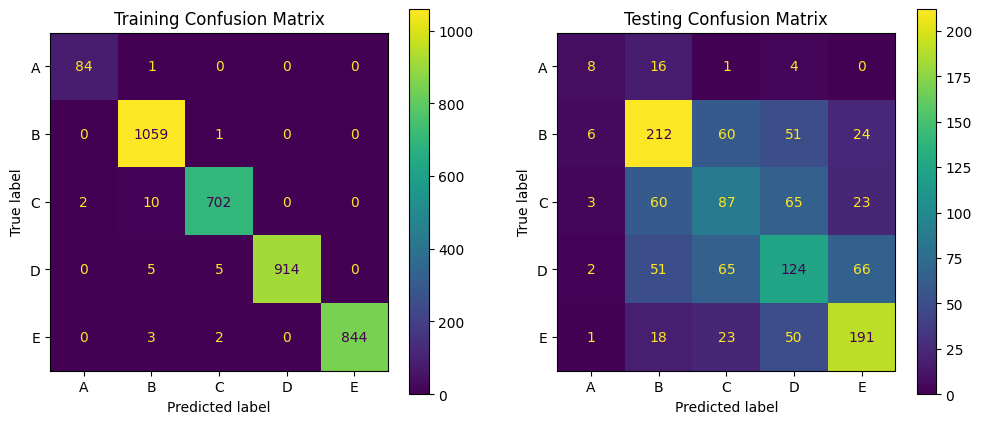

Training Confusion Matrix Results:
[84, 1, 0, 0, 0]
[0, 1059, 1, 0, 0]
[2, 10, 702, 0, 0]
[0, 5, 5, 914, 0]
[0, 3, 2, 0, 844]
Testing Confusion Matrix Results:
[8, 16, 1, 4, 0]
[6, 212, 60, 51, 24]
[3, 60, 87, 65, 23]
[2, 51, 65, 124, 66]
[1, 18, 23, 50, 191]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.40      0.28      0.33        29
           B       0.59      0.60      0.60       353
           C       0.37      0.37      0.37       238
           D       0.42      0.40      0.41       308
           E       0.63      0.67      0.65       283

    accuracy                           0.51      1211
   macro avg       0.48      0.46      0.47      1211
weighted avg       0.51      0.51      0.51      1211

F1 Score: 0.51


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 heuristically selected features

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Fit the Decision Tree Model
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 7. Make Predictions
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# 8. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

Reducing the number of features from 18 to 9 showed a nuanced impact on model performance. While the accuracy on the training set remained consistent, the testing accuracy saw a slight improvement. The F1-scores and weighted averages indicate that the model with fewer features might generalize slightly better, particularly for classes with larger populations.

Therefore, for model optimization, the next step is to apply the class_weight='balanced' parameter. This adjustment aims to address the class imbalances identified in the previous analysis, allowing our model to give more importance to the underrepresented classes during training. This approach should help improve overall performance and accuracy across all classes.

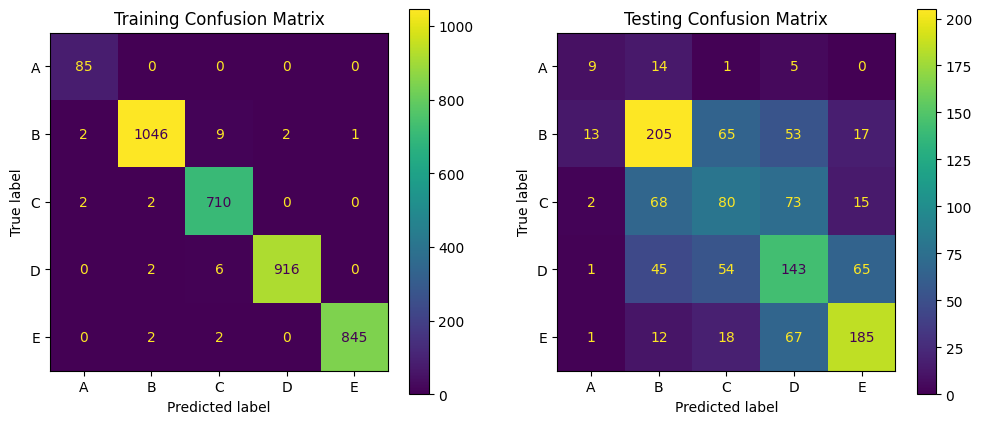

Training Confusion Matrix Results:
[85, 0, 0, 0, 0]
[2, 1046, 9, 2, 1]
[2, 2, 710, 0, 0]
[0, 2, 6, 916, 0]
[0, 2, 2, 0, 845]
Testing Confusion Matrix Results:
[9, 14, 1, 5, 0]
[13, 205, 65, 53, 17]
[2, 68, 80, 73, 15]
[1, 45, 54, 143, 65]
[1, 12, 18, 67, 185]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.35      0.31      0.33        29
           B       0.60      0.58      0.59       353
           C       0.37      0.34      0.35       238
           D       0.42      0.46      0.44       308
           E       0.66      0.65      0.65       283

    accuracy                           0.51      1211
   macro avg       0.48      0.47      0.47      1211
weighted avg       0.51      0.51      0.51      1211

F1 Score: 0.51


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Applying class_weight='balanced' to handle class imbalance

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Fit the Decision Tree Model with class_weight='balanced'
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_classifier.fit(X_train, y_train)

# 7. Make Predictions
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# 8. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=dt_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

For training accuracy the use of the class_weight='balanced' parameter resulted in fewer misclassifications in minority classes, reflecting improved performance in handling class imbalances. As for testing accuracy the model achieved the same accuracy value and so the introduction of class weights did not significantly impact the overall accuracy, suggesting that the model maintained robust performance while better addressing class imbalances. The F1-score for all classes remained comparable. Class E showed a solid performance improvement, while class A saw a slight decline. The overall F1-score was consistent at 0.51 with balanced class weights, indicating a reliable balance between precision and recall in the model's evaluation. Both the macro and weighted averages improved slightly with the class_weight='balanced', suggesting a more equitable performance across classes. This adjustment appears effective in enhancing classification fairness, especially for the minority classes.

Overall, implementing class weights seems to have positively influenced the model’s handling of imbalanced data, leading to better performance for certain classes without sacrificing the overall accuracy. Further exploration of additional techniques, could potentially yield even better results.

The next step in the model refinement process was to apply RandomizedSearchCV, which presents several advantages over the traditional GridSearchCV method. RandomizedSearchCV provides a more efficient exploration of hyperparameters, allowing for quicker tuning without exhaustively searching every combination. This adaptability can lead to a faster identification of hyperparameter settings that maximize model performance, which is particularly useful in larger datasets or more intricate models where time and computational resources are constrained, as is the case here.

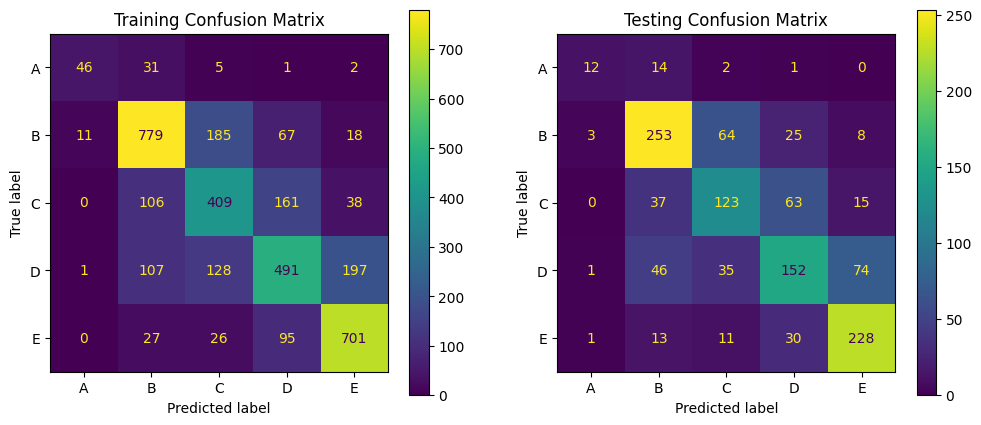

Training Confusion Matrix Results:
[46, 31, 5, 1, 2]
[11, 779, 185, 67, 18]
[0, 106, 409, 161, 38]
[1, 107, 128, 491, 197]
[0, 27, 26, 95, 701]
Testing Confusion Matrix Results:
[12, 14, 2, 1, 0]
[3, 253, 64, 25, 8]
[0, 37, 123, 63, 15]
[1, 46, 35, 152, 74]
[1, 13, 11, 30, 228]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.71      0.41      0.52        29
           B       0.70      0.72      0.71       353
           C       0.52      0.52      0.52       238
           D       0.56      0.49      0.53       308
           E       0.70      0.81      0.75       283

    accuracy                           0.63      1211
   macro avg       0.64      0.59      0.60      1211
weighted avg       0.63      0.63      0.63      1211

F1 Score: 0.63
Best Parameters from RandomizedSearchCV: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': None}


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Applying class_weight='balanced' to handle class imbalance
# Applying RandomizedSearchCV for hyperparameter tuning

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Set up the parameter grid for RandomizedSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

# 7. Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# 8. Conduct RandomizedSearchCV
random_search = RandomizedSearchCV(
    dt_classifier,
    param_distributions=param_grid,
    n_iter=50,  # Adjust the number of iterations as needed
    scoring='f1_weighted',  # You can adjust the scoring metric if needed
    n_jobs=-1,  # Use all available cores
    cv=5,  # Number of folds for cross-validation
    random_state=42
)

# 9. Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# 10. Get the best estimator from random search
best_classifier = random_search.best_estimator_

# 11. Make Predictions using the best estimator
y_train_pred = best_classifier.predict(X_train)
y_test_pred = best_classifier.predict(X_test)

# 11. Make Predictions using the best estimator
y_train_pred = best_classifier.predict(X_train)
y_test_pred = best_classifier.predict(X_test)

# 12. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

# Print best parameters from RandomizedSearchCV
print("Best Parameters from RandomizedSearchCV:", random_search.best_params_)

The RandomizedGridSearchCV approach effectively tuned parameters to enhance the model’s overall performance. The model's ability to classify instances correctly, especially for classes A and E, indicates the impact of hyperparameter tuning. With the obtained values, the execution was proceeded with GridSearchCV.

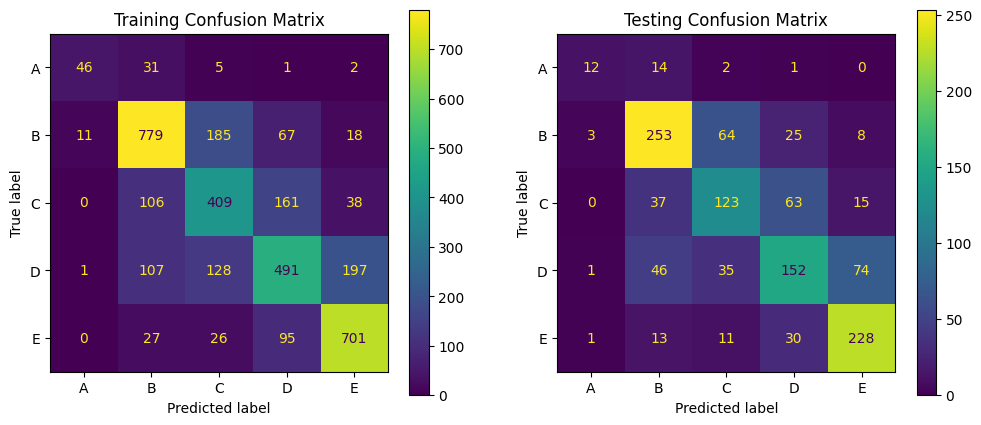

Training Confusion Matrix Results:
[46, 31, 5, 1, 2]
[11, 779, 185, 67, 18]
[0, 106, 409, 161, 38]
[1, 107, 128, 491, 197]
[0, 27, 26, 95, 701]
Testing Confusion Matrix Results:
[12, 14, 2, 1, 0]
[3, 253, 64, 25, 8]
[0, 37, 123, 63, 15]
[1, 46, 35, 152, 74]
[1, 13, 11, 30, 228]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.71      0.41      0.52        29
           B       0.70      0.72      0.71       353
           C       0.52      0.52      0.52       238
           D       0.56      0.49      0.53       308
           E       0.70      0.81      0.75       283

    accuracy                           0.63      1211
   macro avg       0.64      0.59      0.60      1211
weighted avg       0.63      0.63      0.63      1211

F1 Score: 0.63
Best Parameters from GridSearchCV: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Applying class_weight='balanced' to handle class imbalance
# Applying GridSearchCV for hyperparameter tuning

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Set up the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'class_weight': [None]
}

# 7. Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# 8. Conduct GridSearchCV
grid_search = GridSearchCV(
    dt_classifier,
    param_grid=param_grid,
    scoring='f1_weighted',  # You can adjust the scoring metric if needed
    n_jobs=-1,  # Use all available cores
    cv=5  # Number of folds for cross-validation
)

# 9. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 10. Get the best estimator from grid search
best_classifier = grid_search.best_estimator_

# 11. Make Predictions using the best estimator
y_train_pred = best_classifier.predict(X_train)
y_test_pred = best_classifier.predict(X_test)

# 12. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

# Print best parameters from GridSearchCV
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

As expected, the results from the latest model are very similar or identical to previous results, demonstrating consistency in classification performance. The tuning process with GridSearchCV did not significantly alter the outcomes but confirmed the robustness of the model's performance across multiple metrics. Efforts were also made to improve the results by slightly varying the parameters obtained from RandomizedSearchCV, adjusting the values of max_depth, min_samples_split, and min_samples_leaf within a small range.

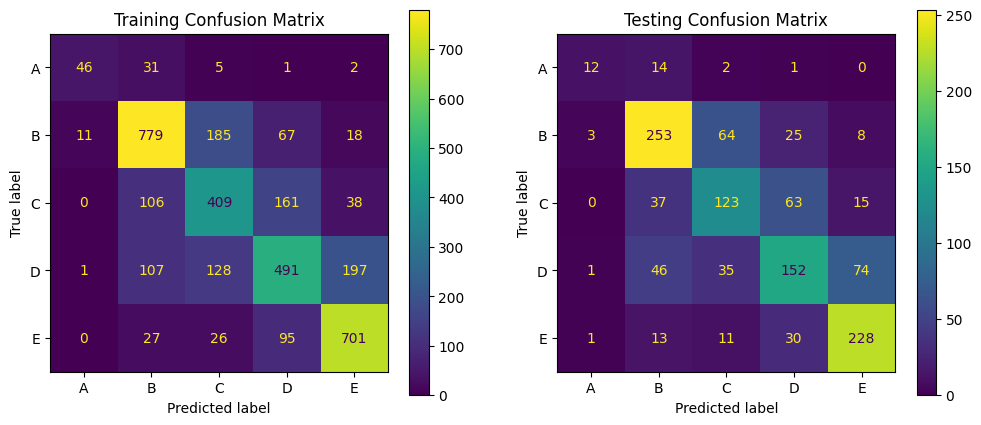

Training Confusion Matrix Results:
[46, 31, 5, 1, 2]
[11, 779, 185, 67, 18]
[0, 106, 409, 161, 38]
[1, 107, 128, 491, 197]
[0, 27, 26, 95, 701]
Testing Confusion Matrix Results:
[12, 14, 2, 1, 0]
[3, 253, 64, 25, 8]
[0, 37, 123, 63, 15]
[1, 46, 35, 152, 74]
[1, 13, 11, 30, 228]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.71      0.41      0.52        29
           B       0.70      0.72      0.71       353
           C       0.52      0.52      0.52       238
           D       0.56      0.49      0.53       308
           E       0.70      0.81      0.75       283

    accuracy                           0.63      1211
   macro avg       0.64      0.59      0.60      1211
weighted avg       0.63      0.63      0.63      1211

F1 Score: 0.63
Best Parameters from GridSearchCV: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4}


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Applying class_weight='balanced' to handle class imbalance
# Applying GridSearchCV for hyperparameter tuning

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Set up the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5, 6, 7],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1,2],
    'class_weight': [None]
}

# 7. Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# 8. Conduct GridSearchCV
grid_search = GridSearchCV(
    dt_classifier,
    param_grid=param_grid,
    scoring='f1_weighted',  # You can adjust the scoring metric if needed
    n_jobs=-1,  # Use all available cores
    cv=5  # Number of folds for cross-validation
)

# 9. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 10. Get the best estimator from grid search
best_classifier = grid_search.best_estimator_

# 11. Make Predictions using the best estimator
y_train_pred = best_classifier.predict(X_train)
y_test_pred = best_classifier.predict(X_test)

# 12. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

# Print best parameters from GridSearchCV
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

There was no change in the results, so it was decided to apply stratified K-folds to the model in order to optimize the results and achieve greater robustness.

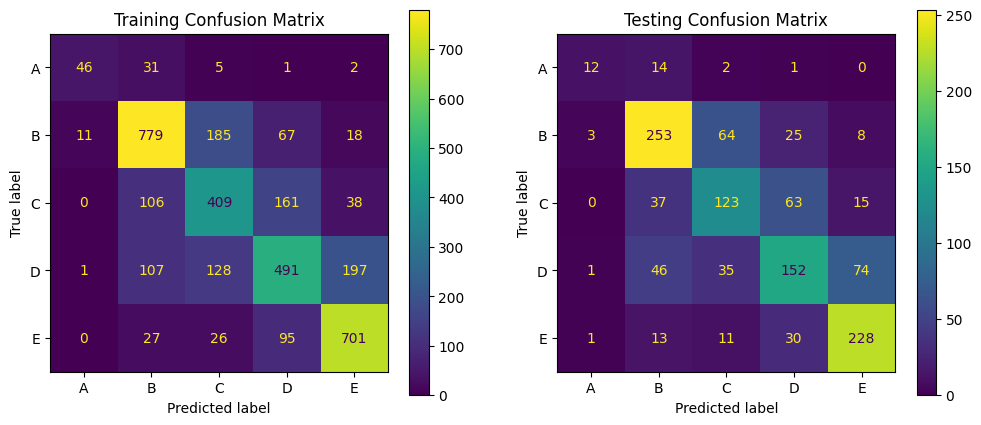

Training Confusion Matrix Results:
[46, 31, 5, 1, 2]
[11, 779, 185, 67, 18]
[0, 106, 409, 161, 38]
[1, 107, 128, 491, 197]
[0, 27, 26, 95, 701]
Testing Confusion Matrix Results:
[12, 14, 2, 1, 0]
[3, 253, 64, 25, 8]
[0, 37, 123, 63, 15]
[1, 46, 35, 152, 74]
[1, 13, 11, 30, 228]
Classification Report (Test Data):
               precision    recall  f1-score   support

           A       0.71      0.41      0.52        29
           B       0.70      0.72      0.71       353
           C       0.52      0.52      0.52       238
           D       0.56      0.49      0.53       308
           E       0.70      0.81      0.75       283

    accuracy                           0.63      1211
   macro avg       0.64      0.59      0.60      1211
weighted avg       0.63      0.63      0.63      1211

F1 Score: 0.63
Best Parameters from GridSearchCV: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4}


In [ ]:
# Decision Tree Classifier for TARGET_D with 9 features selected based on correlation with pearson coefficient and ANOVA test
# Applying class_weight='balanced' to handle class imbalance
# Applying GridSearchCV for hyperparameter tuning with Stratified K-Folds

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Read data and prepare DONATION_TYPE from TARGET_D
df_original = pd.read_csv("Donors_dataset.csv")
df_cls = df_original.copy()

# Define numeric and categorical features
numeric_features = [
    "RECENT_AVG_GIFT_AMT",
    "LAST_GIFT_AMT",
    "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT",
    "LIFETIME_MAX_GIFT_AMT"
]

categorical_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

def donation_type(amount):
    if amount >= 50:
        return "A"
    elif 20 <= amount < 50:
        return "B"
    elif 13 <= amount < 20:
        return "C"
    elif 10 <= amount < 13:
        return "D"
    else:
        return "E"

# Keep only rows where TARGET_D is not null and create DONATION_TYPE
df_cls_non_null = df_cls[df_cls["TARGET_D"].notnull()].copy()
df_cls_non_null["DONATION_TYPE"] = df_cls_non_null["TARGET_D"].apply(donation_type)

# Base for the model
df_D = df_cls_non_null[['DONATION_TYPE'] + numeric_features + categorical_features].copy()

# 2. Imputation of missing values
num_imputer = SimpleImputer(strategy="median")
df_D[numeric_features] = num_imputer.fit_transform(df_D[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_D[categorical_features] = cat_imputer.fit_transform(df_D[categorical_features])

# 3. Separate X and y
X_D_full = df_D[numeric_features + categorical_features]
y_D_full = df_D['DONATION_TYPE']

# 4. Transform categorical variables using one-hot encoding
X_D_full = pd.get_dummies(X_D_full, columns=categorical_features)

# 5. Split the data again after transforming it
X_train, X_test, y_train, y_test = train_test_split(
    X_D_full, y_D_full, random_state=42, stratify=y_D_full
)

# 6. Set up the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5],
    'min_samples_split': [4],
    'min_samples_leaf': [1],
    'class_weight': [None]
}

# 7. Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# 8. Define Stratified K-Folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 9. Conduct GridSearchCV with Stratified K-Folds
grid_search = GridSearchCV(
    dt_classifier,
    param_grid=param_grid,
    scoring='f1_weighted',
    n_jobs=-1,
    cv=skf  # Using StratifiedKFold for cross-validation
)

# 10. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 11. Get the best estimator from grid search
best_classifier = grid_search.best_estimator_

# 12. Make Predictions using the best estimator
y_train_pred = best_classifier.predict(X_train)
y_test_pred = best_classifier.predict(X_test)

# 13. Evaluate the Model

# Confusion Matrix for Training Data
confusion_mtx_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ConfusionMatrixDisplay(confusion_mtx_train, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Training Confusion Matrix")

# Confusion Matrix for Testing Data
confusion_mtx_test = confusion_matrix(y_test, y_test_pred)
plt.subplot(1, 2, 2)
ConfusionMatrixDisplay(confusion_mtx_test, display_labels=best_classifier.classes_).plot(ax=plt.gca())
plt.title("Testing Confusion Matrix")

plt.show()

# Display confusion matrix results in the specified format
print("Training Confusion Matrix Results:")
for row in confusion_mtx_train:
    print(row.tolist())

print("Testing Confusion Matrix Results:")
for row in confusion_mtx_test:
    print(row.tolist())

# Classification Report
print("Classification Report (Test Data):\n", classification_report(y_test, y_test_pred))

# F1 Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score: {f1:.2f}")

# Print best parameters from GridSearchCV
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

About the overall performance, the accuracy of the model is 63%, indicating a moderate level of predictive performance across the classes. For Class A, precision is 0.71, indicating that a good proportion of instances predicted as class A were actually class A. Recall is 0.41, suggesting that the model missed a significant number of actual class A instances. The F1-Score of 0.52 reflects the trade-off between precision and recall, showing room for improvement.

For Class B, precision is 0.70 and recall is 0.72, demonstrating a balanced performance, making it the most reliable class. The F1-Score of 0.71 indicates a strong ability to identify class B.

In Class C, both precision and recall are 0.52, implying difficulties in classifying instances correctly, as the model struggles to differentiate this class effectively. For Class D, precision is 0.56 and recall is 0.49, suggesting similar issues as Class C—marking it as another area needing attention. Finally, in Class E, there is strong performance, with precision of 0.70 and recall of 0.81. The F1-Score of 0.75 indicates good classification accuracy in this category.

Regarding macro and weighted averages, the macro average F1-Score of 0.60 indicates an overall average across all classes, showing that while some classes performed well, others significantly pull down the average. The weighted average of 0.63 gives more importance to the larger classes, reflecting a more optimistic overall performance.

As for the best parameters: class_weight: None, criterion: 'entropy', max_depth: 5, min_samples_leaf: 1, min_samples_split: 4. These parameters suggest a balanced approach that avoids overfitting while capturing useful data patterns.

In conclusion, at this stage, the model demonstrates strengths and weaknesses across different classes. Classes B and E show strong performance, while improvements are needed for Classes A, C, and D. To enhance the model further, several approaches can be implemented, with the most relevant being Model Selection, which includes experimenting with different algorithms, such as ensemble methods (e.g., Random Forest, XGBoost) or other classifiers that might perform better on the dataset.

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...